<a href="https://colab.research.google.com/github/jcmachicao/MachineLearningAvanzado_UC_2025/blob/main/U2__Validaci%C3%B3n_y_Testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# RED NEURONAL SIMPLE EN PYTORCH
# Training vs Validation Loss

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

In [2]:
# 1. GENERAR DATASET

X, y = make_classification(
    n_samples=1500,
    n_features=10,
    n_informative=6,
    n_classes=3,
    random_state=42
)

# 2. SPLIT: TRAIN / VALIDATION / TEST

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25,
    random_state=42
)

# 3. NORMALIZACIÓN

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)


# 4. CONVERTIR A TENSORES

X_train = torch.tensor(X_train, dtype=torch.float32)
X_val   = torch.tensor(X_val, dtype=torch.float32)
X_test  = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_val   = torch.tensor(y_val, dtype=torch.long)
y_test  = torch.tensor(y_test, dtype=torch.long)


# 5. DEFINIR RED NEURONAL
class SimpleNN(nn.Module):

    def __init__(self):
        super(SimpleNN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(10, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 3)
        )

    def forward(self, x):
        return self.network(x)

model = SimpleNN()

Epoch 01/20 | Train Loss: 1.1032 | Validation Loss: 1.0979
Epoch 02/20 | Train Loss: 1.1012 | Validation Loss: 1.0958
Epoch 03/20 | Train Loss: 1.0992 | Validation Loss: 1.0938
Epoch 04/20 | Train Loss: 1.0971 | Validation Loss: 1.0917
Epoch 05/20 | Train Loss: 1.0951 | Validation Loss: 1.0897
Epoch 06/20 | Train Loss: 1.0930 | Validation Loss: 1.0876
Epoch 07/20 | Train Loss: 1.0909 | Validation Loss: 1.0855
Epoch 08/20 | Train Loss: 1.0888 | Validation Loss: 1.0835
Epoch 09/20 | Train Loss: 1.0867 | Validation Loss: 1.0814
Epoch 10/20 | Train Loss: 1.0846 | Validation Loss: 1.0793
Epoch 11/20 | Train Loss: 1.0825 | Validation Loss: 1.0773
Epoch 12/20 | Train Loss: 1.0803 | Validation Loss: 1.0752
Epoch 13/20 | Train Loss: 1.0781 | Validation Loss: 1.0731
Epoch 14/20 | Train Loss: 1.0759 | Validation Loss: 1.0710
Epoch 15/20 | Train Loss: 1.0737 | Validation Loss: 1.0688
Epoch 16/20 | Train Loss: 1.0714 | Validation Loss: 1.0667
Epoch 17/20 | Train Loss: 1.0691 | Validation Loss: 1.06

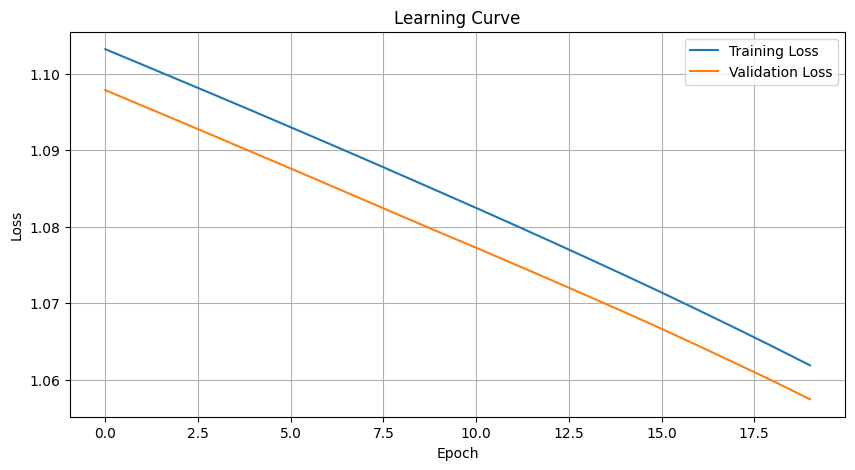

In [3]:
# 6. LOSS Y OPTIMIZER

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

# 7. TRAINING LOOP + VALIDATION

epochs = 20

train_losses = []
val_losses = []

for epoch in range(epochs):

    # TRAINING
    # -----------------------------
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    train_loss = criterion(outputs, y_train)
    train_loss.backward()
    optimizer.step()

    # VALIDATION
    # -----------------------------
    model.eval()

    with torch.no_grad():
        val_outputs = model(X_val)
        val_loss = criterion(val_outputs, y_val)

    # Guardar pérdidas
    train_losses.append(train_loss.item())
    val_losses.append(val_loss.item())

    print(
        f"Epoch {epoch+1:02d}/{epochs} | "
        f"Train Loss: {train_loss.item():.4f} | "
        f"Validation Loss: {val_loss.item():.4f}"
    )


# 8. EVALUACIÓN FINAL EN TEST
model.eval()

with torch.no_grad():
    test_outputs = model(X_test)
    predictions = torch.argmax(test_outputs, dim=1)
    accuracy = (predictions == y_test).float().mean()
print("\nTest Accuracy:", accuracy.item())

# 9. CURVA DE APRENDIZAJE
plt.figure(figsize=(10,5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Learning Curve")
plt.legend()
plt.grid(True)
plt.show()